# DAS Event Classification — Results Visualization

Generates all figures and LaTeX tables for the paper comparing CNN, MLP, and MS-SNN on the DAS dataset.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import pandas as pd
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf',
    'text.usetex': False,
    # 'pdf.fonttype': 42,
    # 'ps.fonttype': 42,
    # 'font.sans-serif': ['DejaVu Stans', 'Arial', 'Liberation Sans'],
    # 'font.family': 'sans-serif',
    # 'pdf.use14corefonts': False,  # Don't use PostScript core fonts
    # 'axes.unicode_minus': False   # Use ASCII minus instead of unicode
})

In [2]:
# Pretty Confusion Matrix Functions
# Based on code by Wagner Cipriano and Phongsathorn Kittiworapanya
from pandas import DataFrame
from matplotlib.collections import QuadMesh
from matplotlib.colors import LinearSegmentedColormap

# Create a gradient from white to darker red for better visibility
colors = [(1.0, 0.95, 0.95), (0.95, 0.5, 0.45), (0.8, 0.2, 0.2)]
cm_cmap = LinearSegmentedColormap.from_list('cm_color', colors, N=256)

def get_new_fig(fn, figsize=[9,9]):
    """Init graphics"""
    fig1 = plt.figure(fn, figsize)
    ax1 = fig1.gca()    # Get Current Axis
    ax1.cla()   # clear existing plot
    return fig1, ax1

def configcell_text_and_colors(array_df, lin, col, oText, facecolors, posi, fz, fmt, show_null_values=0):
    """
    config cell text and colors
    and return text elements to add and to dell
    """
    text_add = []
    text_del = []
    cell_val = array_df[lin][col]
    tot_all = array_df[-1][-1]
    per = (float(cell_val) / tot_all) * 100
    curr_column = array_df[:,col]
    ccl = len(curr_column)

    # last line and/or last column
    if(col == (ccl - 1)) or (lin == (ccl - 1)):
        # tots and percents
        if(cell_val != 0):
            if(col == ccl - 1) and (lin == ccl - 1):
                tot_rig = 0
                for i in range(array_df.shape[0] - 1):
                    tot_rig += array_df[i][i]
                per_ok = (float(tot_rig) / cell_val) * 100
            elif(col == ccl - 1):
                tot_rig = array_df[lin][lin]
                per_ok = (float(tot_rig) / cell_val) * 100
            elif(lin == ccl - 1):
                tot_rig = array_df[col][col]
                per_ok = (float(tot_rig) / cell_val) * 100
            per_err = 100 - per_ok
        else:
            per_ok = per_err = 0

        per_ok_s = ['%.2f%%'%(per_ok), '100%'][int(per_ok == 100)]

        # text to DEL
        text_del.append(oText)

        # text to ADD
        font_prop = fm.FontProperties(size=fz)
        text_kwargs = dict(color='black', ha="center", va="center", gid='sum', fontproperties=font_prop)
        lis_txt = ['%d'%(cell_val), per_ok_s, '%.2f%%'%(per_err)]
        lis_kwa = [text_kwargs]
        dic = text_kwargs.copy(); dic['color'] = 'g'; lis_kwa.append(dic);
        dic = text_kwargs.copy(); dic['color'] = 'r'; lis_kwa.append(dic);
        lis_pos = [(oText._x, oText._y-0.25), (oText._x, oText._y), (oText._x, oText._y+0.25)]
        for i in range(len(lis_txt)):
            newText = dict(x=lis_pos[i][0], y=lis_pos[i][1], text=lis_txt[i], kw=lis_kwa[i])
            text_add.append(newText)

        # set background color for sum cells (last line and last column)
        carr = np.array([0.7, 0.7, 0.7, 1.0])
        if(col == ccl - 1) and (lin == ccl - 1):
            carr = np.array([0.5, 0.5, 0.5, 1.0])
        facecolors[posi] = carr

    else:
        if(per > 0):
            txt = '$\\mathbf{%s}$\n%.2f%%' %(cell_val, per)
        else:
            if(show_null_values == 0):
                txt = ''
            elif(show_null_values == 1):
                txt = '0'
            else:
                txt = '$\\mathbf{0}$\n0.0%%'
        oText.set_text(txt)

        # main diagonal
        if(col == lin):
            # set color of the text in the diagonal to black for visibility
            oText.set_color('black')
            # set background color in the diagonal to bright green
            facecolors[posi] = np.array([0.3, 0.9, 0.3, 1.0])

    return text_add, text_del

def insert_totals(df_cm):
    """insert total column and line (the last ones)"""
    sum_col = []
    for c in df_cm.columns:
        sum_col.append(df_cm[c].sum())
    sum_lin = []
    for item_line in df_cm.iterrows():
        sum_lin.append(item_line[1].sum())
    df_cm['sum_lin'] = sum_lin
    sum_col.append(np.sum(sum_lin))
    df_cm.loc['sum_col'] = sum_col

def plot_pretty_confusion_matrix(df_cm, annot=True, cmap=cm_cmap, fmt='.2f', fz=18,
      lw=2, cbar=False, figsize=[5,5], show_null_values=2, pred_val_axis='y'):
    """
    print conf matrix with default layout (like matlab)
    """
    if(pred_val_axis in ('col', 'x')):
        xlbl = 'Predicted'
        ylbl = 'Actual'
    else:
        xlbl = 'Actual'
        ylbl = 'Predicted'
        df_cm = df_cm.T

    # create "Total" column
    insert_totals(df_cm)

    # Create figure
    fig, ax1 = get_new_fig('Conf matrix default', figsize)

    # Get data as numpy array
    data = df_cm.values
    n_rows, n_cols = data.shape
    
    # Create custom color array for each cell
    # Start with all cells using the red colormap
    from matplotlib import cm as mpl_cm
    norm = plt.Normalize(vmin=data.min(), vmax=data.max())
    colors_matrix = np.zeros((n_rows, n_cols, 4))
    
    # Calculate separate normalizations for diagonal and sum cells
    diag_values = [data[i, i] for i in range(min(n_rows - 1, n_cols - 1))]
    sum_values = []
    for i in range(n_rows - 1):
        sum_values.append(data[i, n_cols - 1])
    for j in range(n_cols - 1):
        sum_values.append(data[n_rows - 1, j])
    
    norm_diag = plt.Normalize(vmin=min(diag_values) if diag_values else 0, vmax=max(diag_values) if diag_values else 1)
    norm_sum = plt.Normalize(vmin=min(sum_values) if sum_values else 0, vmax=max(sum_values) if sum_values else 1)
    
    # Apply colors based on cell type
    for i in range(n_rows):
        for j in range(n_cols):
            # Diagonal cells (excluding sum) - GREEN GRADIENT
            if i == j and i < n_rows - 1:
                val = norm_diag(data[i, j])
                # Green gradient: light green to darker green
                colors_matrix[i, j] = [0.7 - val * 0.5, 0.95 - val * 0.15, 0.7 - val * 0.5, 1.0]
            # Sum column (excluding corner) - LIGHT GREEN GRADIENT
            elif j == n_cols - 1 and i < n_rows - 1:
                val = norm_sum(data[i, j])
                colors_matrix[i, j] = [0.85 - val * 0.15, 0.95 - val * 0.1, 0.85 - val * 0.15, 1.0]
            # Sum row (excluding corner) - LIGHT GREEN GRADIENT
            elif i == n_rows - 1 and j < n_cols - 1:
                val = norm_sum(data[i, j])
                colors_matrix[i, j] = [0.85 - val * 0.15, 0.95 - val * 0.1, 0.85 - val * 0.15, 1.0]
            # Corner (total) - LIGHT GRAY
            elif i == n_rows - 1 and j == n_cols - 1:
                colors_matrix[i, j] = [0.9, 0.9, 0.9, 1.0]
            # All other cells - RED gradient (much stronger red)
            else:
                # Use red colormap with much stronger red color
                val = norm(data[i, j])
                # Range from light pink (low values) to strong red (high values)
                colors_matrix[i, j] = [1.0, 0.95 - val * 0.75, 0.95 - val * 0.75, 1.0]
    
    # Draw the heatmap using imshow with our custom colors (rasterized for smaller file size)
    ax1.imshow(colors_matrix, aspect='auto', interpolation='nearest', rasterized=True)
    
    # Explicitly turn off grid
    ax1.grid(False)
    
    # Set limits
    ax1.set_xlim(-0.5, n_cols - 0.5)
    ax1.set_ylim(n_rows - 0.5, -0.5)
    
    # Turn off spines (borders)
    for spine in ax1.spines.values():
        spine.set_visible(False)
    
    # Turn off ticks
    ax1.tick_params(axis='both', which='both', length=0)
    
    # Set tick labels
    ax1.set_xticks(range(n_cols))
    ax1.set_yticks(range(n_rows))
    ax1.set_xticklabels(df_cm.columns, ha='right', rotation=45)
    ax1.set_yticklabels(df_cm.index, va='center')

    # Now add text annotations
    array_df = np.array(df_cm.to_records(index=False).tolist())
    for i in range(n_rows):
        for j in range(n_cols):
            cell_val = array_df[i][j]
            tot_all = array_df[-1][-1]
            per = (float(cell_val) / tot_all) * 100
            
            # Sum cells
            if i == n_rows - 1 or j == n_cols - 1:
                if cell_val != 0:
                    if i == n_rows - 1 and j == n_cols - 1:
                        tot_rig = sum(array_df[k][k] for k in range(n_rows - 1))
                        per_ok = (float(tot_rig) / cell_val) * 100
                    elif j == n_cols - 1:
                        tot_rig = array_df[i][i]
                        per_ok = (float(tot_rig) / cell_val) * 100
                    else:
                        tot_rig = array_df[j][j]
                        per_ok = (float(tot_rig) / cell_val) * 100
                    per_err = 100 - per_ok
                    per_ok_s = '100%' if per_ok == 100 else f'{per_ok:.2f}%'
                    
                    ax1.text(j, i - 0.25, f'{int(cell_val)}', 
                           ha='center', va='center', fontsize=fz, color='black')
                    ax1.text(j, i, per_ok_s, 
                           ha='center', va='center', fontsize=fz, color='g')
                    ax1.text(j, i + 0.25, f'{per_err:.2f}%', 
                           ha='center', va='center', fontsize=fz, color='r')
            # Regular cells
            else:
                if per > 0:
                    txt = f'$\\mathbf{{{int(cell_val)}}}$\n{per:.2f}%'
                else:
                    txt = '' if show_null_values == 0 else ('0' if show_null_values == 1 else '$\\mathbf{0}$\n0.0%')
                
                ax1.text(j, i, txt, ha='center', va='center', fontsize=fz, color='black')

    # Labels
    ax1.set_xlabel(xlbl)
    ax1.set_ylabel(ylbl)
    
    plt.tight_layout()

def plot_from_confusion_matrix(cm, columns=None, annot=True, cmap=cm_cmap,
      fmt='.2f', fz=18, lw=1, cbar=False, figsize=[5,5], show_null_values=2, pred_val_axis='lin'):
    """Plot confusion matrix from a confusion matrix array."""
    df_cm = DataFrame(cm, index=columns, columns=columns)
    plot_pretty_confusion_matrix(df_cm, fz=fz, lw=lw, cmap=cmap, figsize=figsize, show_null_values=show_null_values, pred_val_axis=pred_val_axis)

print("✓ Pretty confusion matrix functions loaded")

✓ Pretty confusion matrix functions loaded


## 1. Load Results from All Models

In [3]:
from pathlib import Path
import pickle

# Define result directories (update these paths after training)
# CNN_DIR     = "results_cnn_20260120_094712"
# MLP_DIR     = "results_mlp_20260128_070258"
# SIAMESE_DIR = "results_siamese_20260126_035856"

# Automatically extract the last folder from each result path as the experiment/model directory name
CNN_DIR = sorted([str(p) for p in Path('.').glob('results_cnn_*') if p.is_dir()])[-1]
MLP_DIR = sorted([str(p) for p in Path('.').glob('results_mlp_*') if p.is_dir()])[-1]
SIAMESE_DIR = sorted([str(p) for p in Path('.').glob('results_siamese_*') if p.is_dir()])[-1]

print(f"Using directories:\n  CNN: {CNN_DIR}\n  MLP: {MLP_DIR}\n  Siamese: {SIAMESE_DIR}")

OUTPUT_DIR  = "paper_figures"

Path(OUTPUT_DIR).mkdir(exist_ok=True)

def load_results(result_dir, model_name):
    """Load saved results from a training run."""
    results = {'name': model_name, 'dir': result_dir}

    # Load training history
    history_file = Path(result_dir) / 'history.npy'
    if history_file.exists():
        results['history'] = np.load(history_file, allow_pickle=True).item()
        print(f"✓ Loaded {model_name} training history")
    else:
        results['history'] = None

    # Load test results
    test_npy = Path(result_dir) / 'test_results.npy'
    test_json = Path(result_dir) / 'test_results.json'

    if test_npy.exists():
        results['test'] = np.load(test_npy, allow_pickle=True).item()
        print(f"✓ Loaded {model_name} test results")
    elif test_json.exists():
        import json
        with open(test_json, 'r') as f:
            results['test'] = json.load(f)
        print(f"✓ Loaded {model_name} test results")
    else:
        results['test'] = None

    return results


Using directories:
  CNN: results_cnn_20260502_203233
  MLP: results_mlp_20260502_213233
  Siamese: results_siamese_no_decimation_results


In [4]:
# Load all results
print("Loading results...\n")
cnn_results = load_results(CNN_DIR, 'CNN')
mlp_results = load_results(MLP_DIR, 'MLP')
siamese_results = load_results(SIAMESE_DIR, 'Siamese')
print("\nDone!")

Loading results...

✓ Loaded CNN training history
✓ Loaded CNN test results
✓ Loaded MLP training history
✓ Loaded MLP test results

Done!


## 2. Individual Model Visualizations

### 2.1 CNN Classifier

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


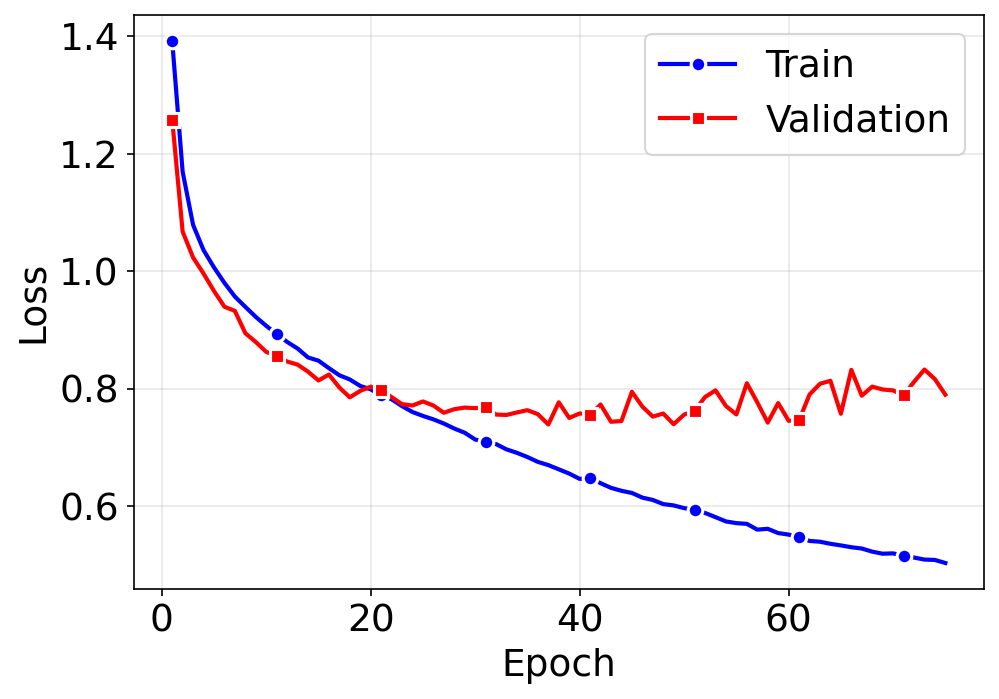

✓ Saved: paper_figures/cnn_loss


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


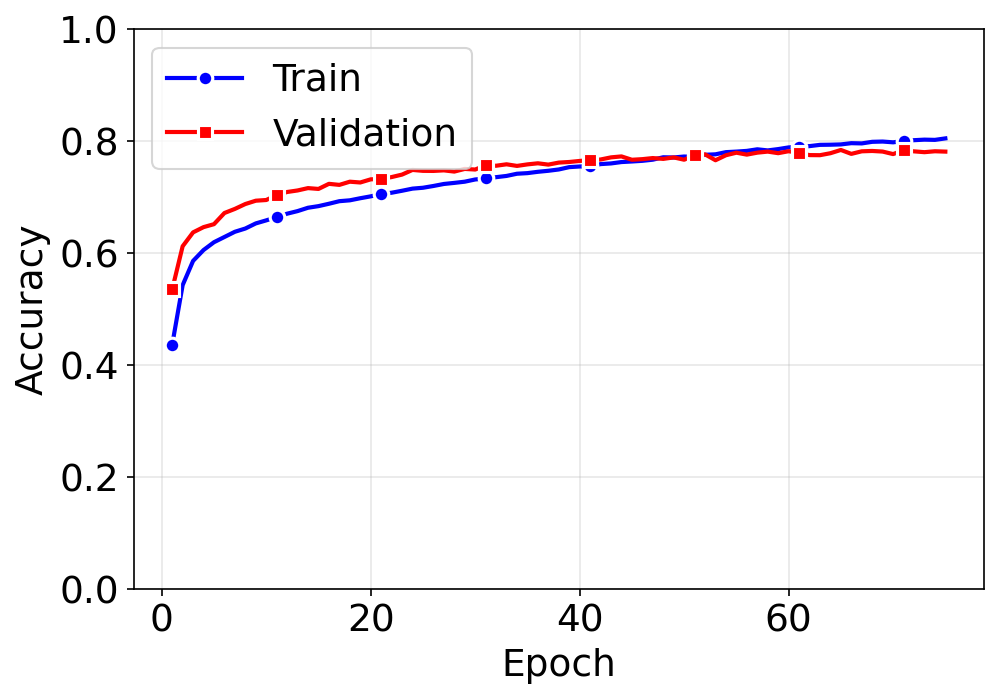

✓ Saved: paper_figures/cnn_accuracy


In [5]:
def plot_loss_curve(history, model_name, filename):
    """Plot loss curve (train and validation)."""
    fig, ax = plt.subplots(figsize=(7, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss with markers
    ax.plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2, 
            marker='o', markersize=7, markevery=10, 
            markeredgecolor='white', markeredgewidth=1.5)
    ax.plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2,
            marker='s', markersize=7, markevery=10,
            markeredgecolor='white', markeredgewidth=1.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    # No title - will be in LaTeX caption
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    for _format in ['png', 'pdf', 'eps', 'svg']:
        plt.savefig(f'{filename}.{_format}')
    plt.show()
    plt.close()
    print(f"✓ Saved: {filename}")

def plot_accuracy_curve(history, model_name, filename):
    """Plot accuracy curve (train and validation)."""
    fig, ax = plt.subplots(figsize=(7, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Determine accuracy key names (Siamese uses different keys)
    train_acc_key = 'train_pair_acc' if 'train_pair_acc' in history else 'train_acc'
    val_acc_key = 'val_pair_acc' if 'val_pair_acc' in history else 'val_acc'
    
    # Accuracy with markers
    ax.plot(epochs, history[train_acc_key], 'b-', label='Train', linewidth=2, 
            marker='o', markersize=7, markevery=10,
            markeredgecolor='white', markeredgewidth=1.5)
    ax.plot(epochs, history[val_acc_key], 'r-', label='Validation', linewidth=2, 
            marker='s', markersize=7, markevery=10,
            markeredgecolor='white', markeredgewidth=1.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    # No title - will be in LaTeX caption
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    for _format in ['png', 'pdf', 'eps', 'svg']:
        plt.savefig(f'{filename}.{_format}')
    plt.show()
    plt.close()

    print(f"✓ Saved: {filename}")

# Plot CNN curves
if cnn_results['history'] is not None:
    plot_loss_curve(
        cnn_results['history'],
        'CNN',
        f'{OUTPUT_DIR}/cnn_loss'
    )
    plot_accuracy_curve(
        cnn_results['history'],
        'CNN',
        f'{OUTPUT_DIR}/cnn_accuracy'
    )

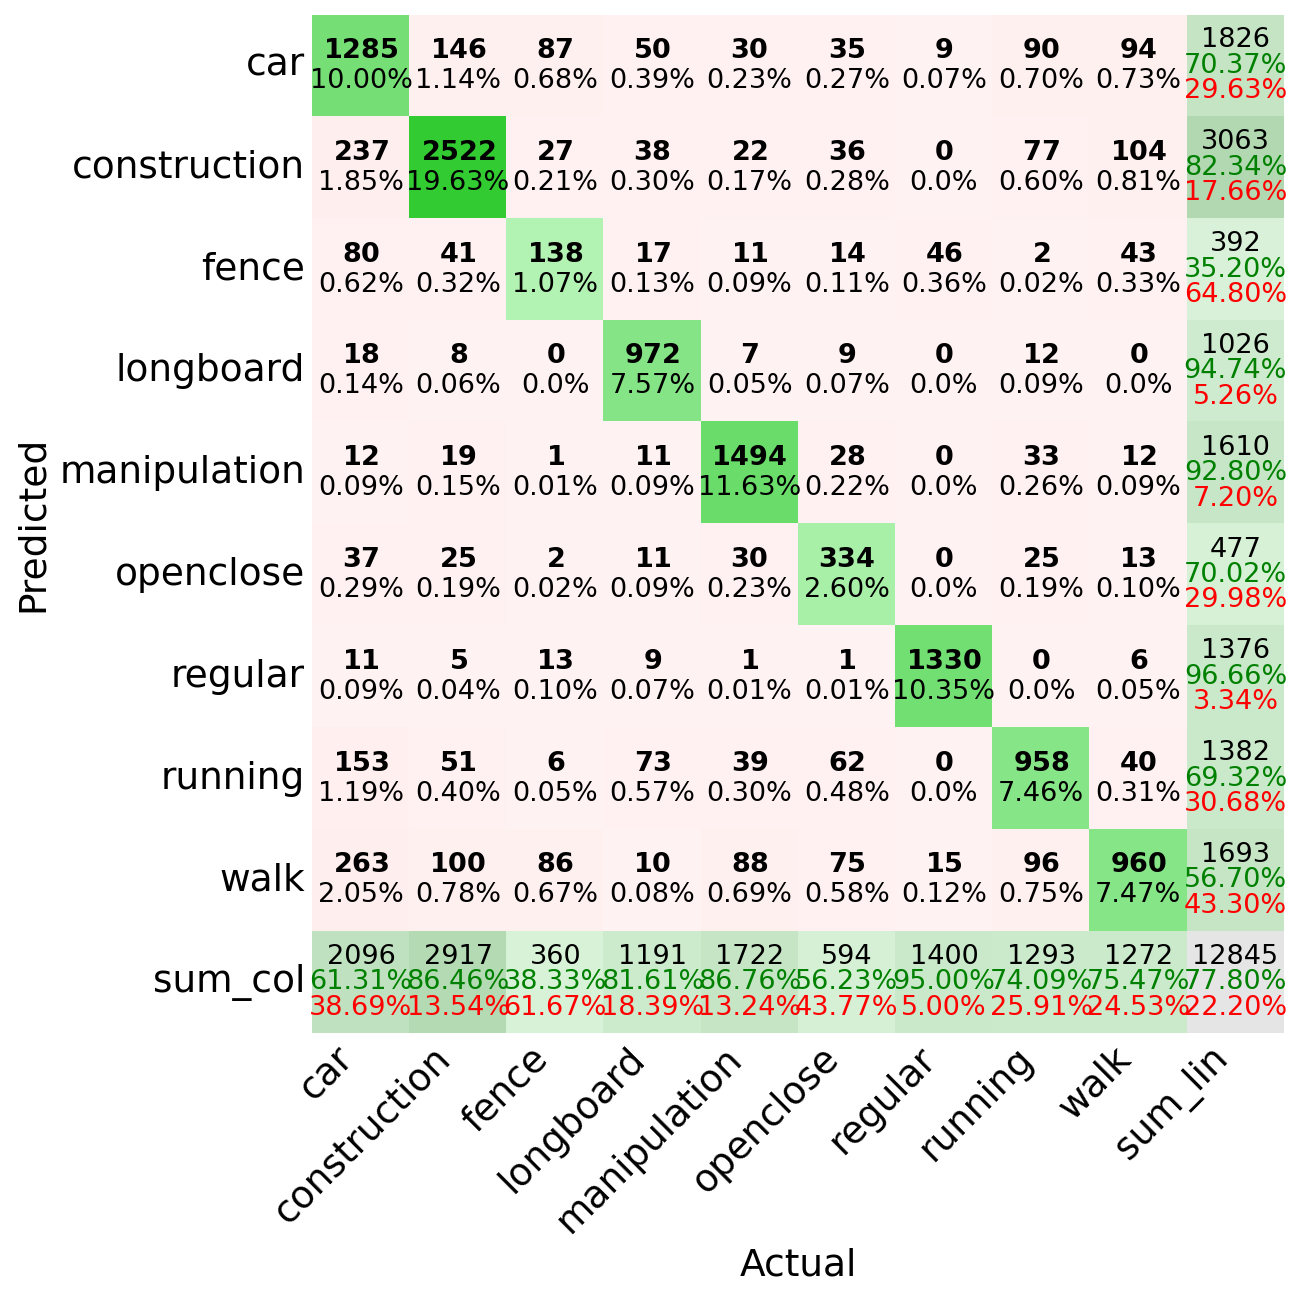

✓ Saved: paper_figures/cnn_confusion_matrix


In [6]:
def plot_confusion_matrix(cm, class_names, filename):
    """Plot confusion matrix using pretty visualization."""
    # Close any existing figures to avoid conflicts
    plt.close('all')
    
    # Use the pretty confusion matrix function
    plot_from_confusion_matrix(
        cm, 
        columns=class_names, 
        figsize=[9, 9], 
        fz=13, 
        lw=1, 
        show_null_values=2, 
        pred_val_axis='lin'
    )
    # plt.savefig(filename, bbox_inches='tight', dpi=150)
    for _format in ['png', 'pdf', 'eps', 'svg']:
        plt.savefig(f'{filename}.{_format}', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close('all')
    print(f"✓ Saved: {filename}")

# Plot CNN confusion matrix
if cnn_results['test'] is not None and 'confusion_matrix' in cnn_results['test']:
    plot_confusion_matrix(
        cnn_results['test']['confusion_matrix'],
        cnn_results['test'].get('class_names', [f'Class {i}' for i in range(9)]),
        f'{OUTPUT_DIR}/cnn_confusion_matrix'
    )

### 2.2 MLP Classifier

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


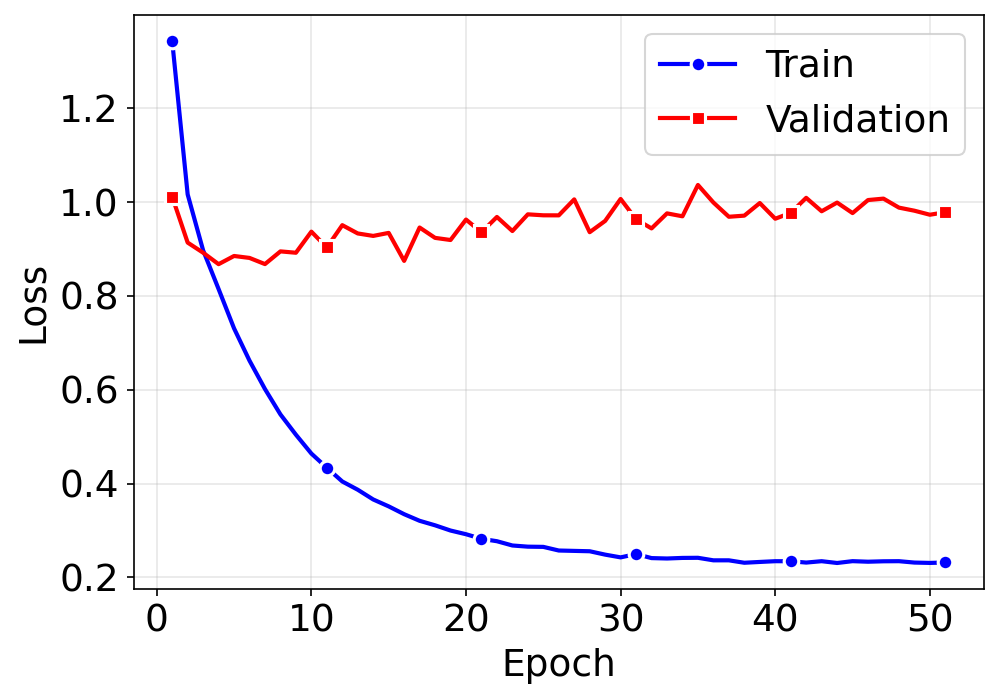

✓ Saved: paper_figures/mlp_loss


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


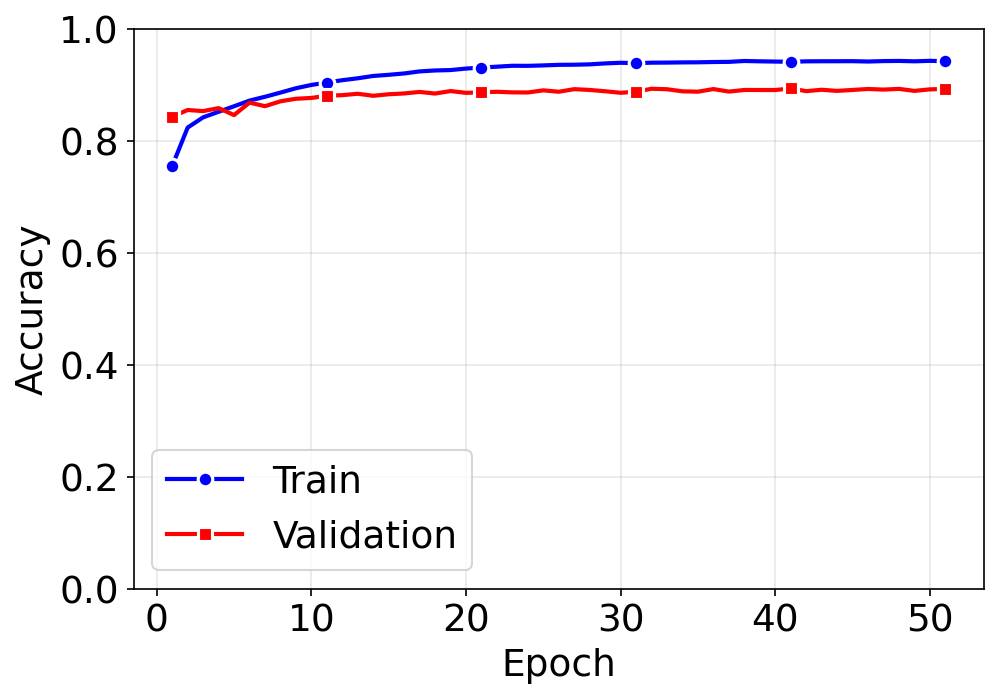

✓ Saved: paper_figures/mlp_accuracy


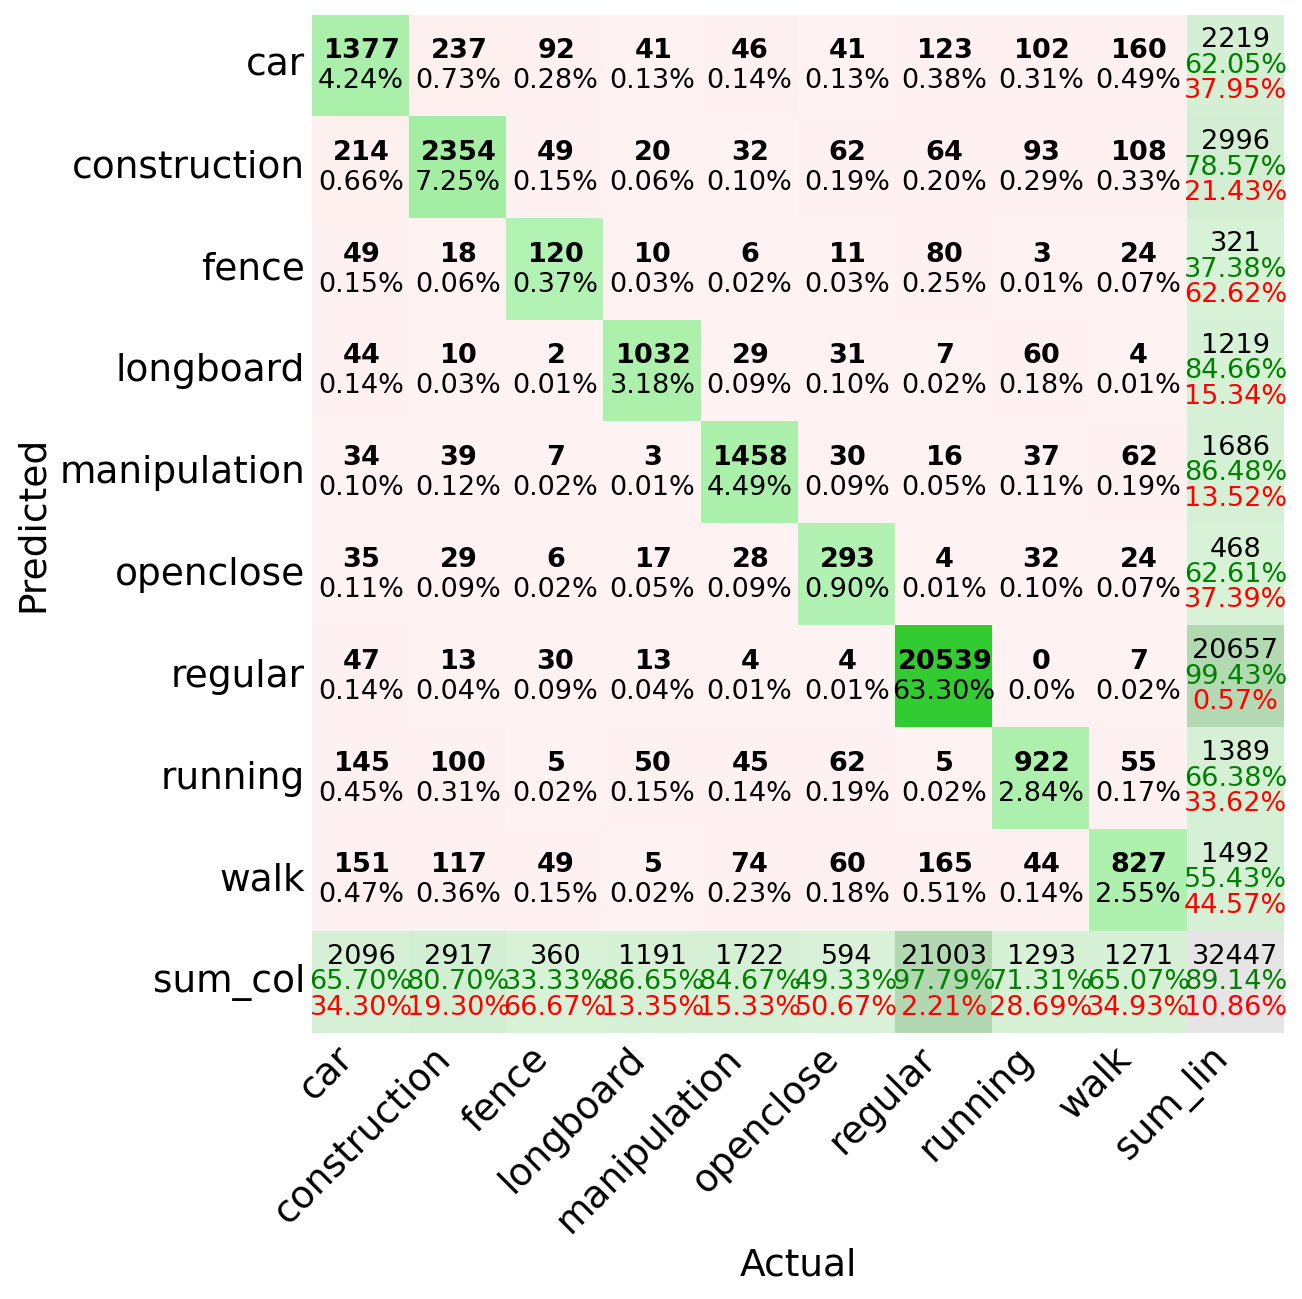

✓ Saved: paper_figures/mlp_confusion_matrix


In [7]:
# Plot MLP training curves
if mlp_results['history'] is not None:
    plot_loss_curve(
        mlp_results['history'],
        'MLP',
        f'{OUTPUT_DIR}/mlp_loss'
    )
    plot_accuracy_curve(
        mlp_results['history'],
        'MLP',
        f'{OUTPUT_DIR}/mlp_accuracy'
    )

# Plot MLP confusion matrix
if mlp_results['test'] is not None and 'confusion_matrix' in mlp_results['test']:
    plot_confusion_matrix(
        mlp_results['test']['confusion_matrix'],
        mlp_results['test'].get('class_names', [f'Class {i}' for i in range(9)]),
        f'{OUTPUT_DIR}/mlp_confusion_matrix'
    )


### 2.3 Siamese Multi-Similarity Network

In [8]:
# Plot Siamese training curves
if siamese_results['history'] is not None:
    plot_loss_curve(
        siamese_results['history'],
        'Siamese',
        f'{OUTPUT_DIR}/siamese_loss'
    )
    plot_accuracy_curve(
        siamese_results['history'],
        'Siamese',
        f'{OUTPUT_DIR}/siamese_accuracy'
    )


#### N-way K-shot Confusion Matrices (Full Test Set)

In [9]:
# Load full test set results (N-way K-shot evaluation)
full_test_file = 'results_siamese_no_decimation_results/siamese_full_test_results.pkl'

try:
    with open(full_test_file, 'rb') as f:
        full_test_results = pickle.load(f)
    print(f"✓ Loaded: {full_test_file}")
    print(f"  Configurations: {list(full_test_results.keys())}")
except FileNotFoundError:
    print(f"⚠ Full test results not found: {full_test_file}")
    full_test_results = None


✓ Loaded: results_siamese_no_decimation_results/siamese_full_test_results.pkl
  Configurations: ['5way_1shot', '5way_5shot', '5way_10shot', '5way_15shot', '5way_20shot', '9way_1shot', '9way_5shot', '9way_10shot', '9way_15shot', '9way_20shot', 'anomaly_detection']


✓ Saved: paper_figures/siamese_9way_1shot_confusion_matrix.svg


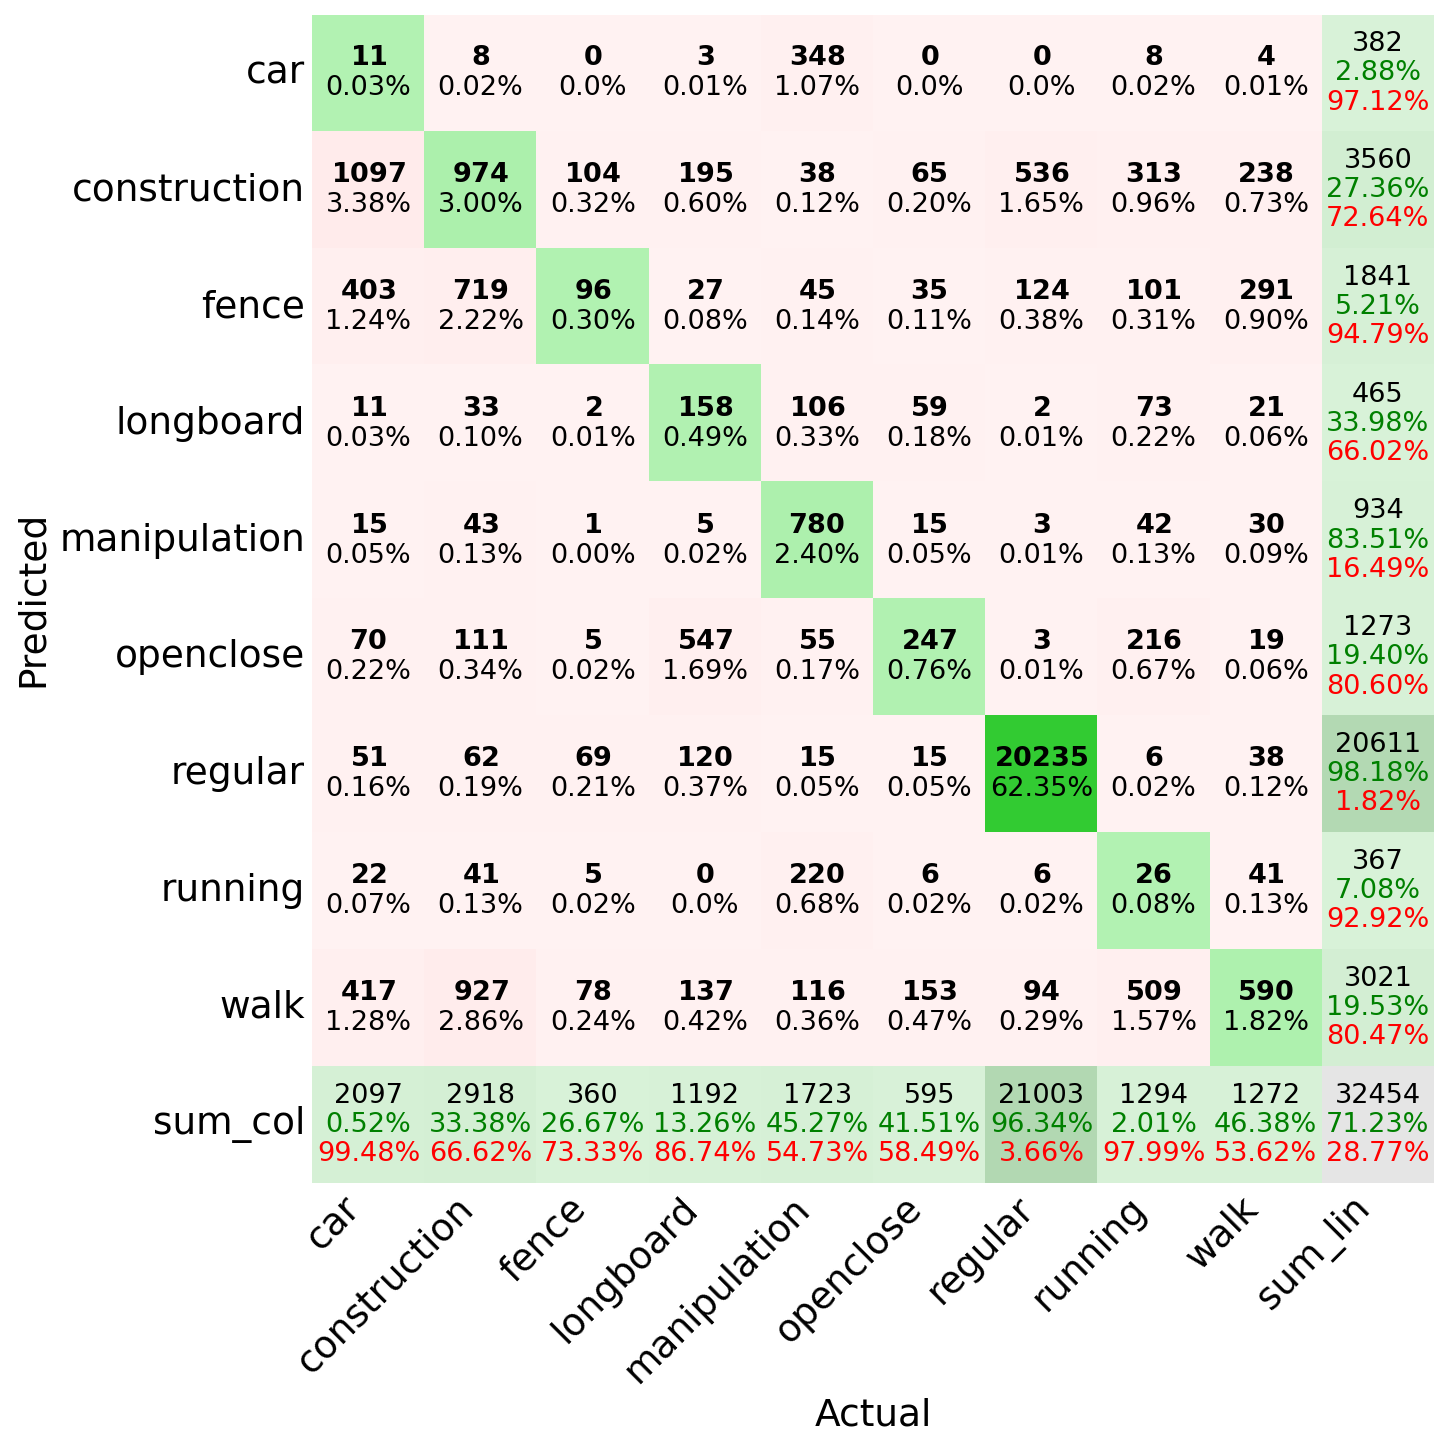

✓ Saved: paper_figures/siamese_9way_5shot_confusion_matrix.svg


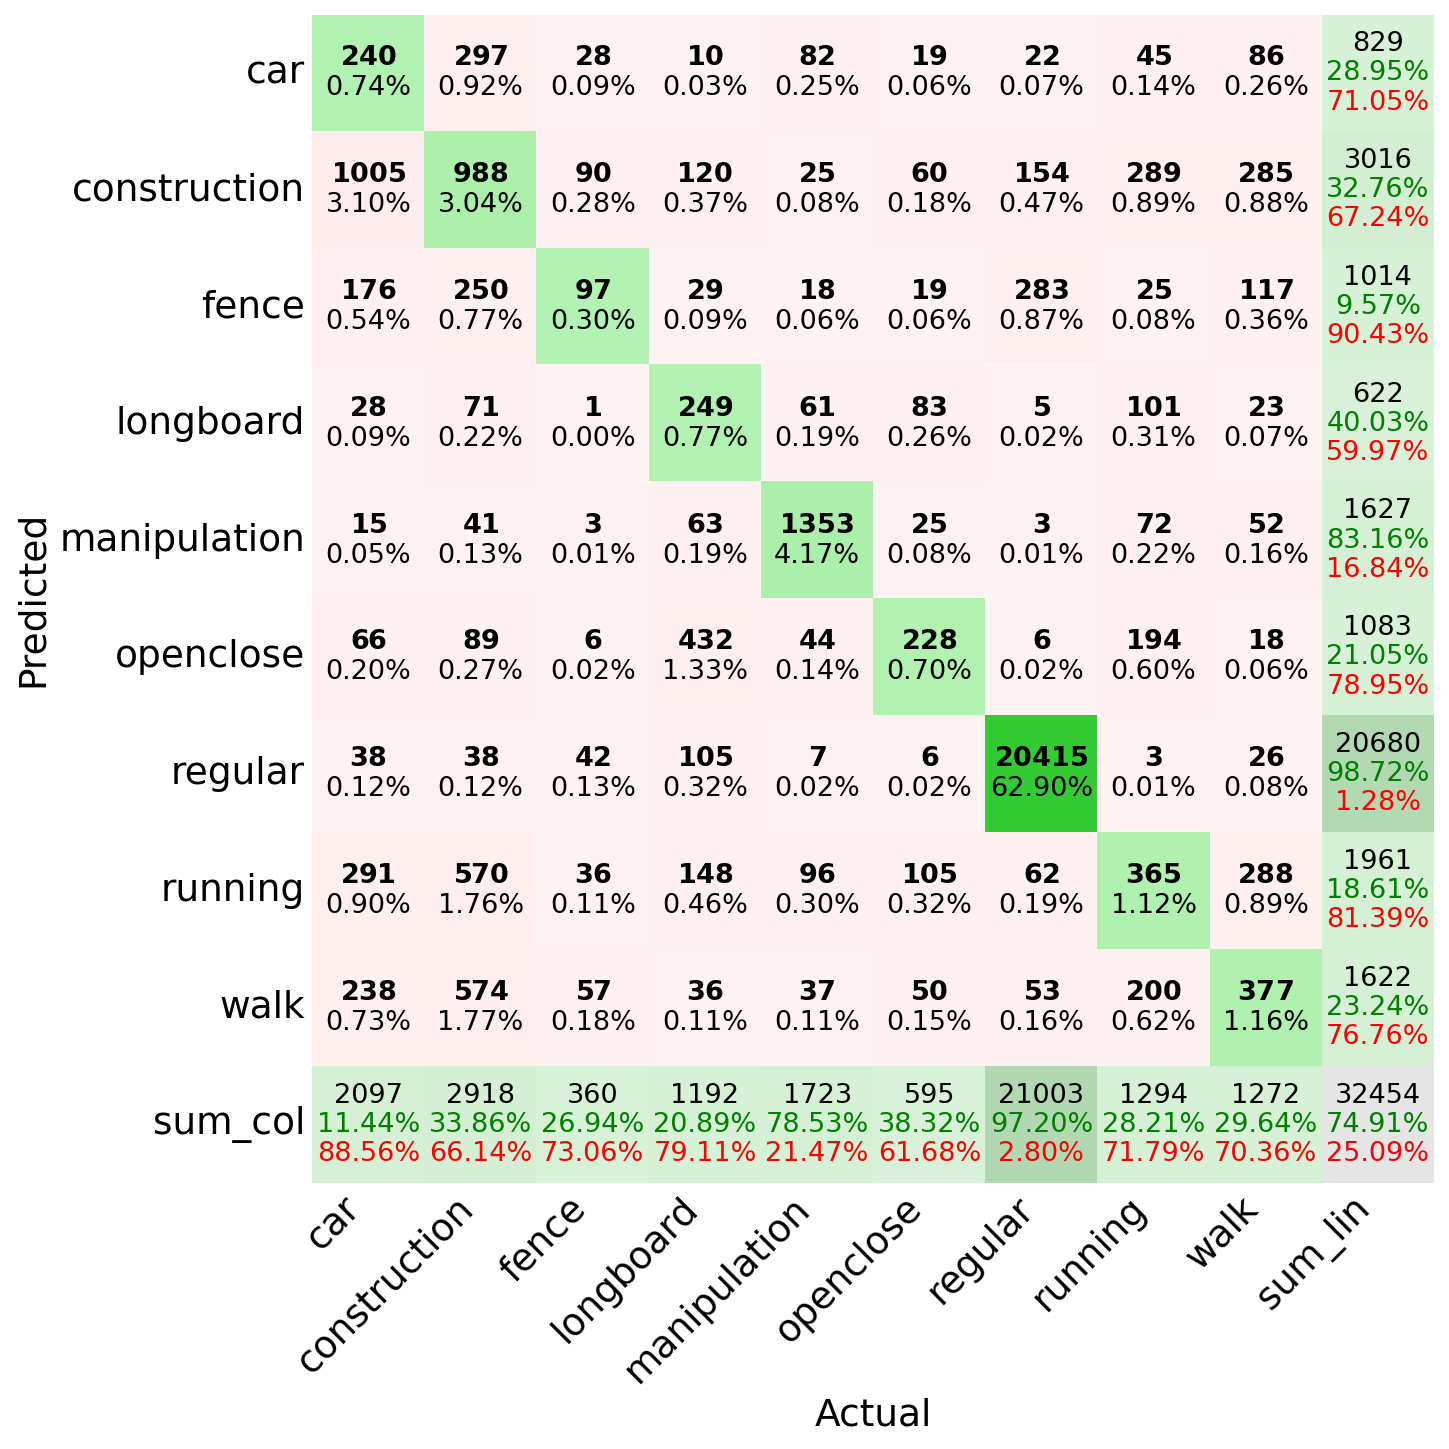

✓ Saved: paper_figures/siamese_9way_10shot_confusion_matrix.svg


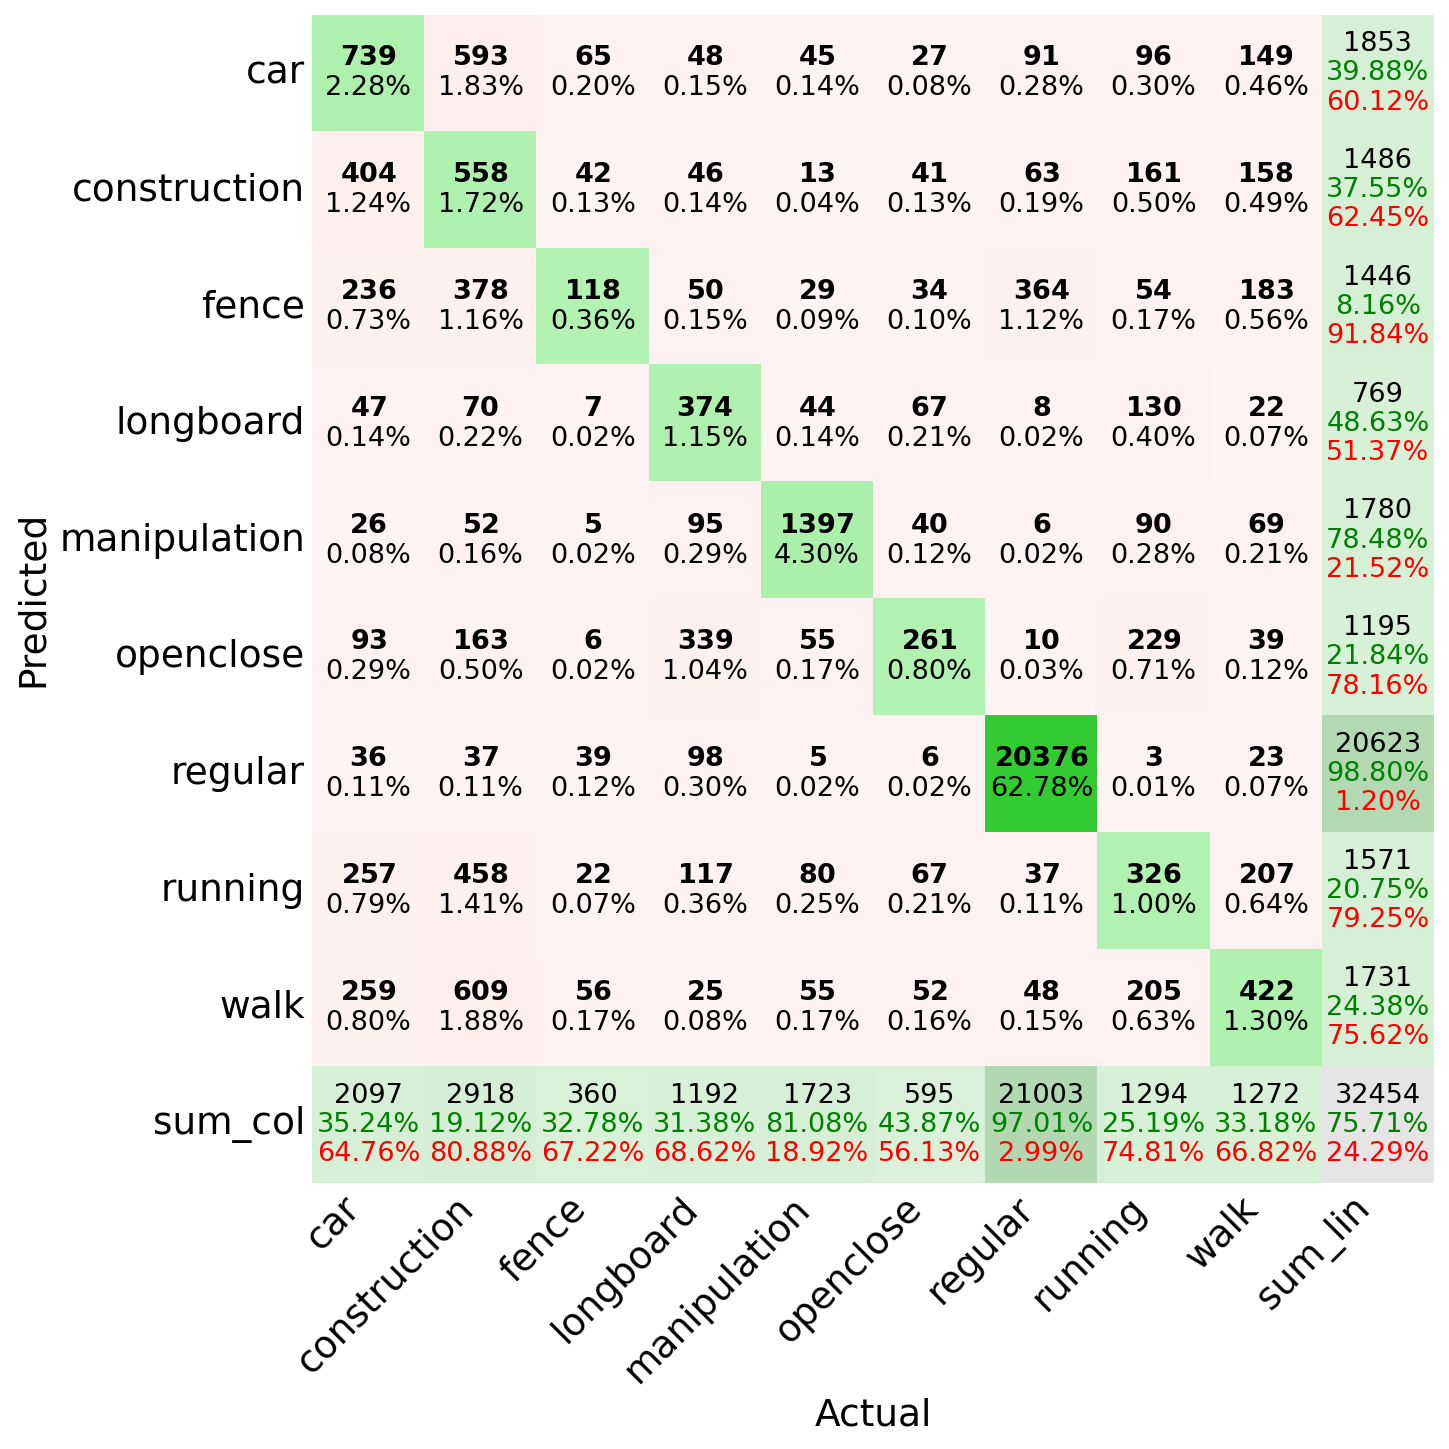

✓ Saved: paper_figures/siamese_9way_15shot_confusion_matrix.svg


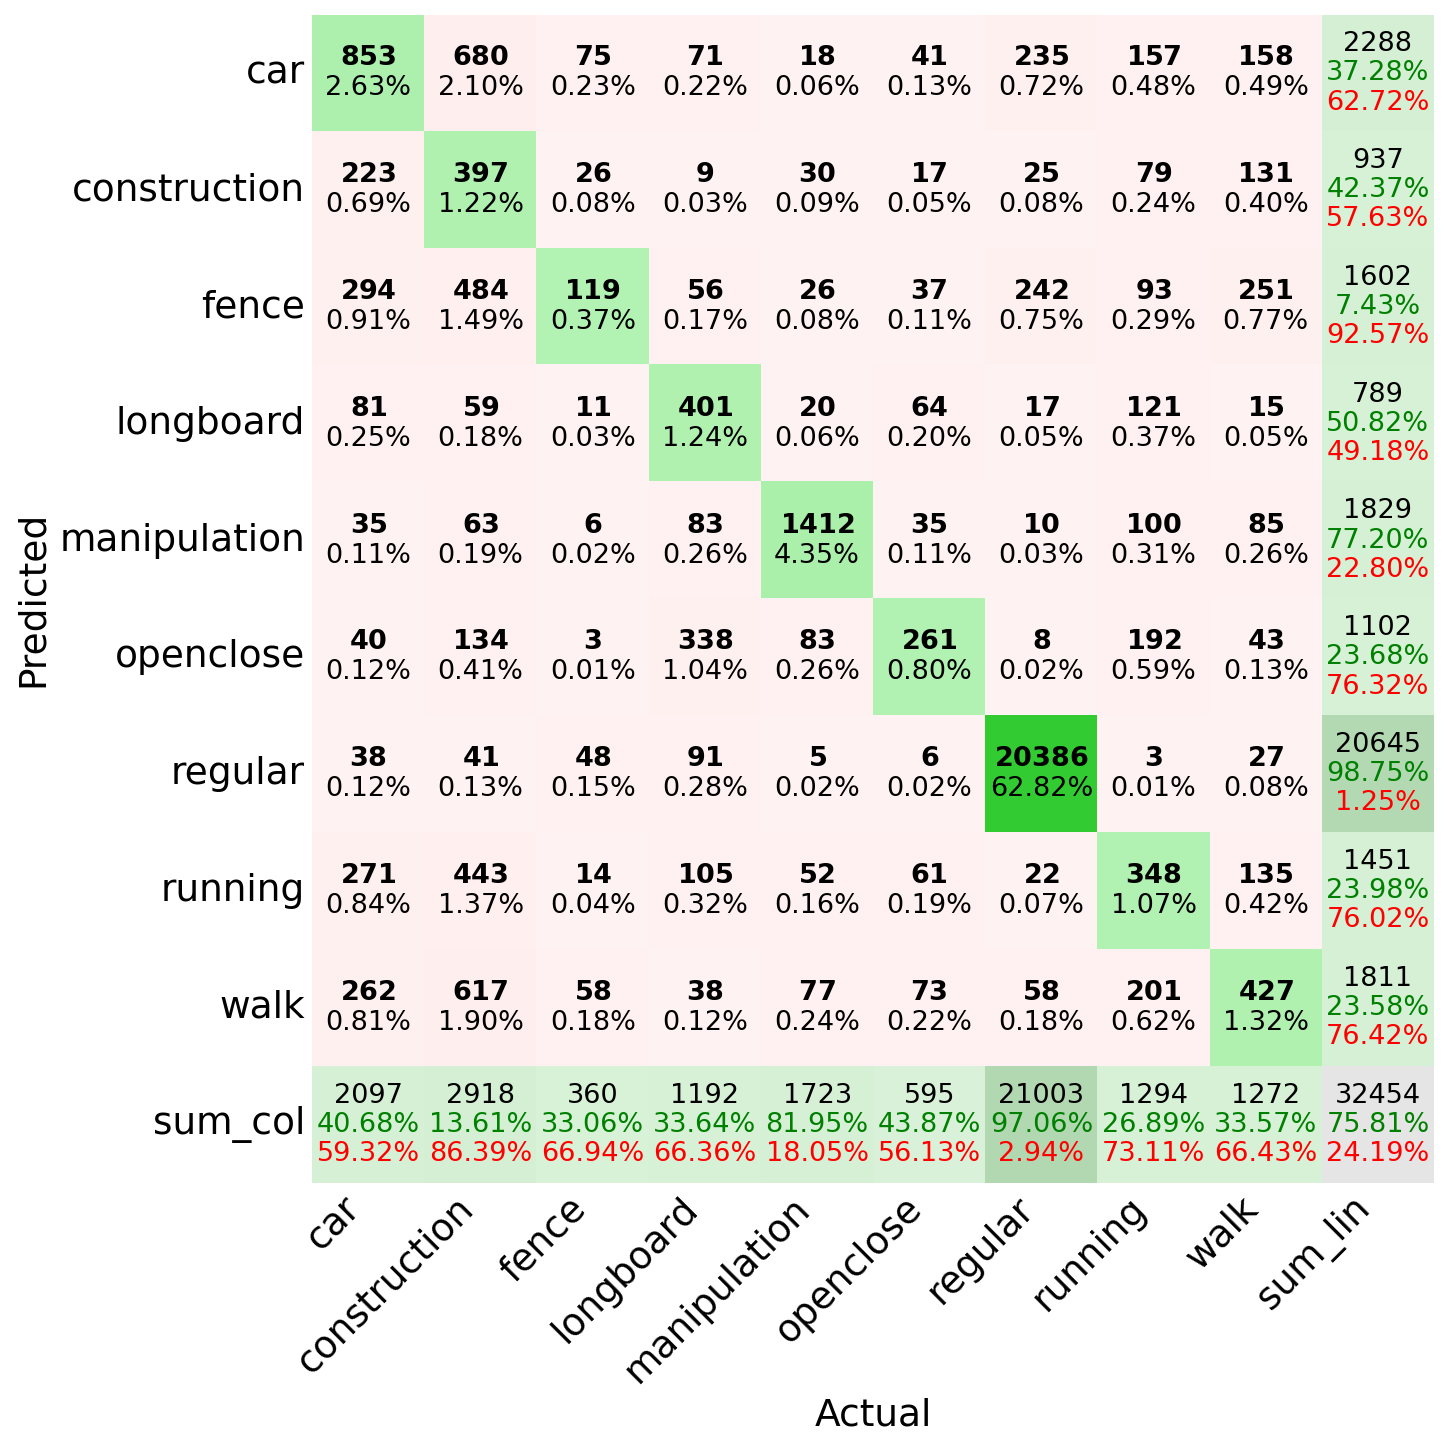

✓ Saved: paper_figures/siamese_9way_20shot_confusion_matrix.svg


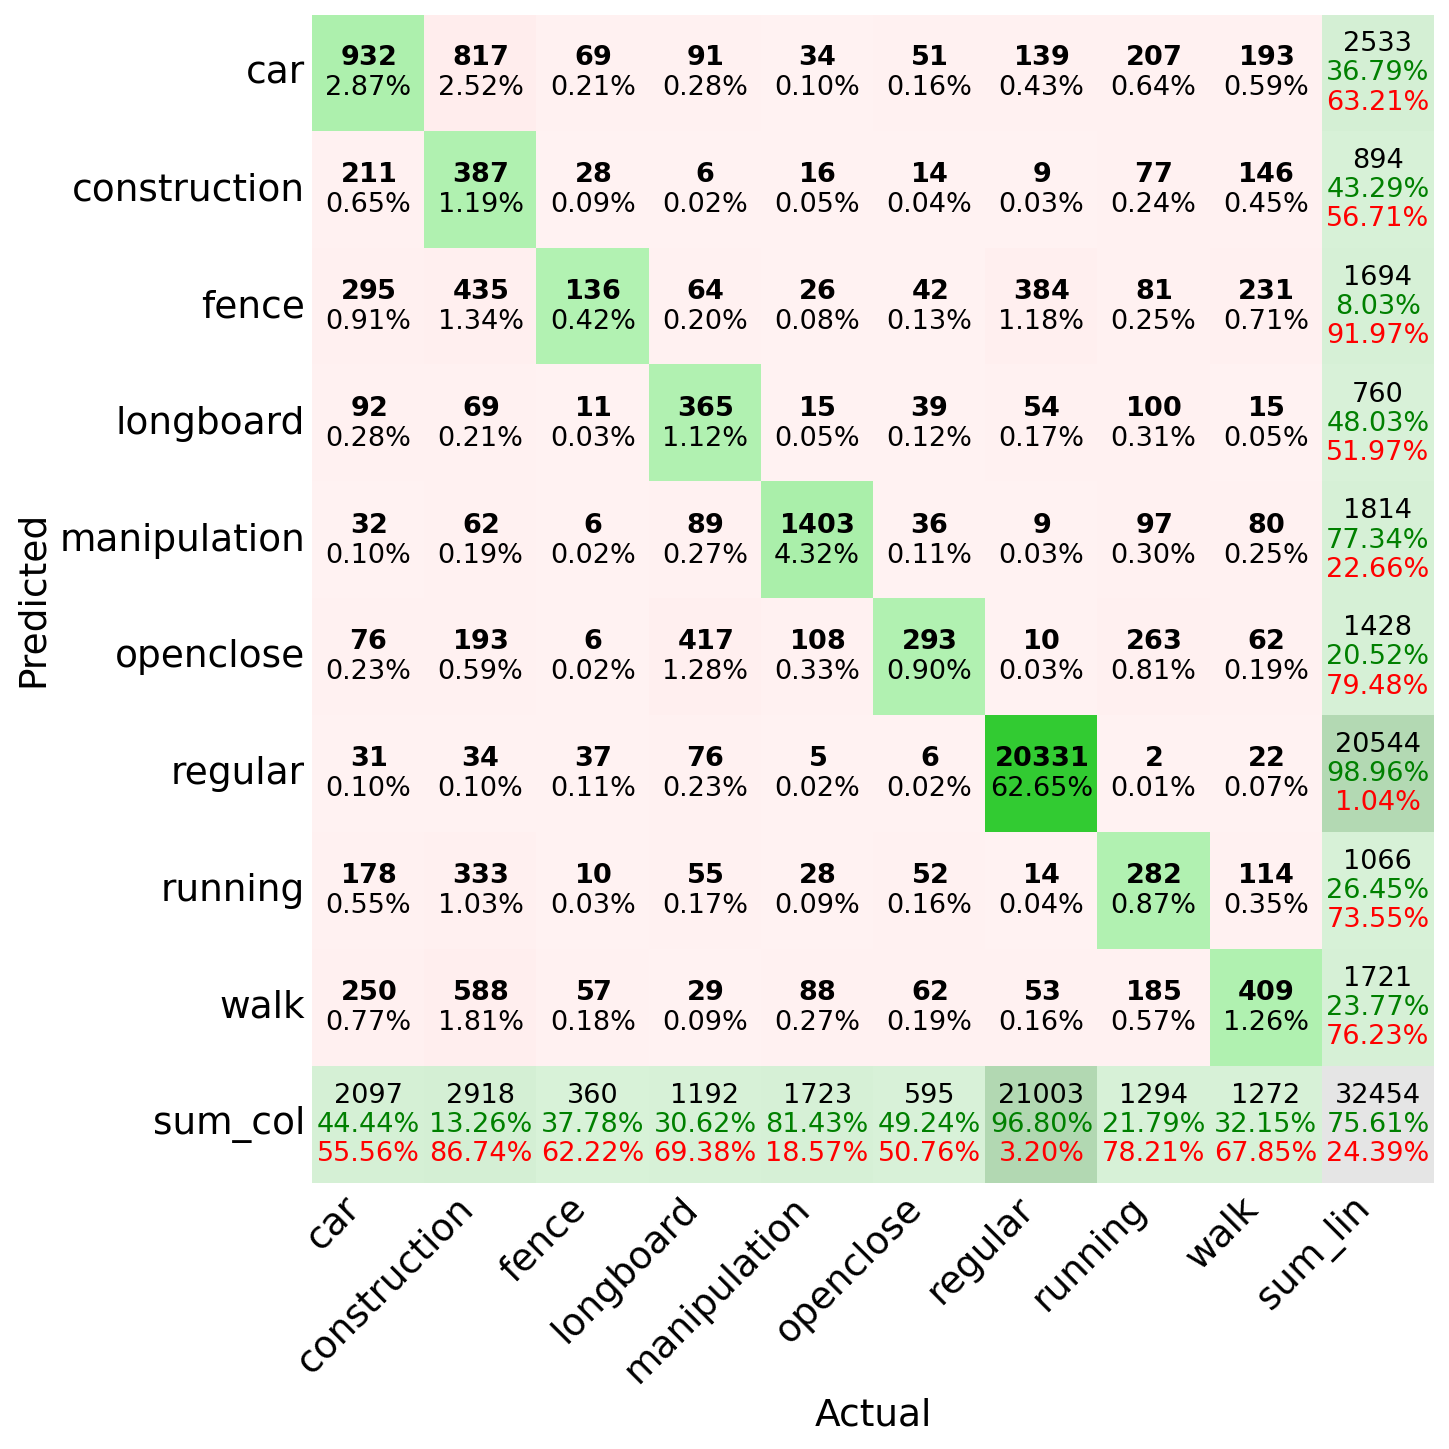

In [10]:
# Plot confusion matrices for all 9-way K-shot configurations
if full_test_results is not None:
    class_names = ['car', 'construction', 'fence', 'longboard', 'manipulation',
                   'openclose', 'regular', 'running', 'walk']

    for k in [1, 5, 10, 15, 20]:
        config_key = f'9way_{k}shot'
        if config_key not in full_test_results:
            print(f"⚠ {config_key} not found")
            continue

        plt.close('all')
        cm = full_test_results[config_key]['confusion_matrix']

        plot_from_confusion_matrix(
            cm,
            columns=class_names,
            figsize=[10, 10],
            fz=13,
            lw=1,
            show_null_values=2,
            pred_val_axis='lin'
        )
        plt.tight_layout()
        for _format in ['png', 'pdf', 'eps', 'svg']:
            fname = f'{OUTPUT_DIR}/siamese_9way_{k}shot_confusion_matrix.{_format}'
            plt.savefig(fname, bbox_inches='tight')
        print(f"✓ Saved: {fname}")
        plt.show()
else:
    print("⚠ Full test results not available")


#### Grouped Bar Chart: All Metrics Comparison

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✓ Saved: paper_figures/grouped_comparison_all_metrics.pdf


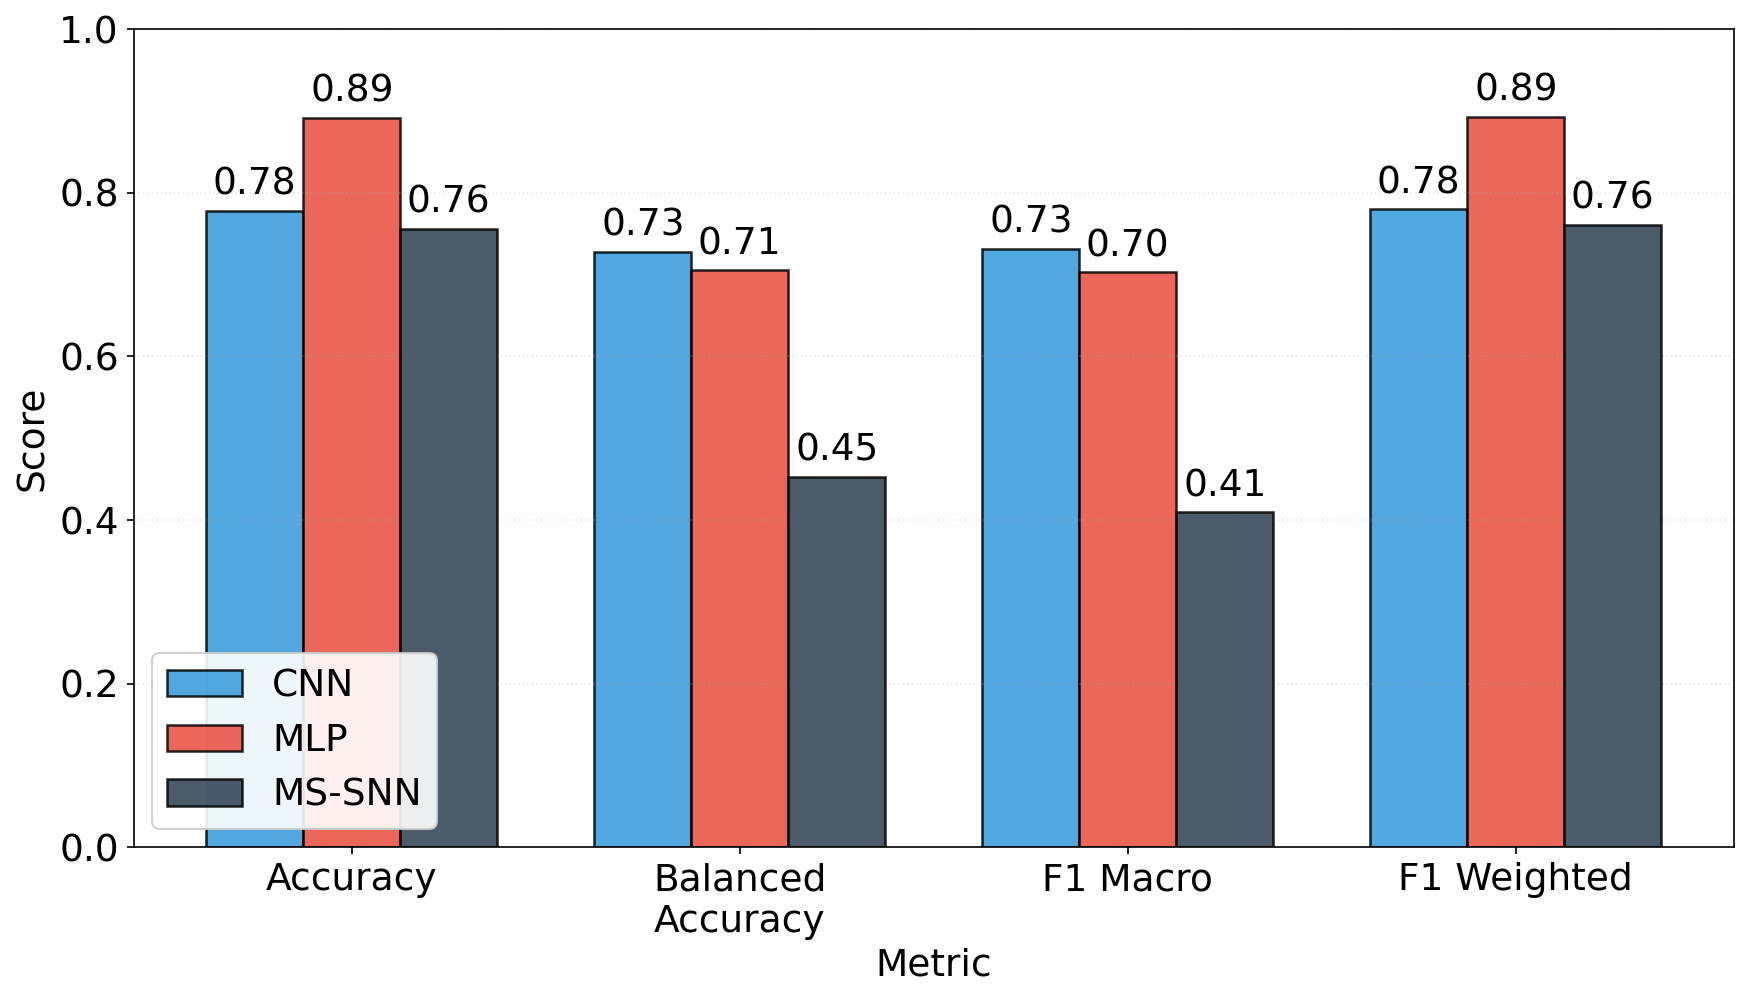

In [11]:
# Grouped Bar Chart: CNN vs MLP vs MS-SNN — All 4 Metrics
if full_test_results is not None and '9way_20shot' in full_test_results:
    metrics = ['Accuracy', 'Balanced\nAccuracy', 'F1 Macro', 'F1 Weighted']

    cnn_values = [
        cnn_results['test']['accuracy'] if cnn_results['test'] else 0,
        cnn_results['test']['balanced_accuracy'] if cnn_results['test'] else 0,
        cnn_results['test']['f1_macro'] if cnn_results['test'] else 0,
        cnn_results['test']['f1_weighted'] if cnn_results['test'] else 0
    ]

    mlp_values = [
        mlp_results['test']['accuracy'] if mlp_results['test'] else 0,
        mlp_results['test']['balanced_accuracy'] if mlp_results['test'] else 0,
        mlp_results['test']['f1_macro'] if mlp_results['test'] else 0,
        mlp_results['test']['f1_weighted'] if mlp_results['test'] else 0
    ]

    siamese_full = full_test_results['9way_20shot']
    siamese_values = [
        siamese_full['accuracy'],
        siamese_full['balanced_accuracy'],
        siamese_full['f1_macro'],
        siamese_full['f1_weighted']
    ]

    x = np.arange(len(metrics))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 7))
    colors = ['#3498db', '#e74c3c', '#2c3e50']

    bars1 = ax.bar(x - width, cnn_values, width, label='CNN', color=colors[0],
                   alpha=0.85, edgecolor='black', linewidth=1.2, zorder=1)
    bars2 = ax.bar(x, mlp_values, width, label='MLP', color=colors[1],
                   alpha=0.85, edgecolor='black', linewidth=1.2, zorder=1)
    bars3 = ax.bar(x + width, siamese_values, width, label='MS-SNN',
                   color=colors[2], alpha=0.85, edgecolor='black', linewidth=1.2, zorder=2)

    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=18, zorder=11)

    ax.set_ylabel('Score')
    ax.set_xlabel('Metric')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim([0, 1.0])
    legend = ax.legend(loc='lower left', framealpha=0.9)
    legend.set_zorder(10)
    ax.grid(True, alpha=0.3, axis='y', linestyle=':', zorder=0)

    plt.tight_layout()
    for _format in ['png', 'pdf', 'eps', 'svg']:
        plt.savefig(f'{OUTPUT_DIR}/grouped_comparison_all_metrics.{_format}', bbox_inches='tight', dpi=150)
    print(f"✓ Saved: {OUTPUT_DIR}/grouped_comparison_all_metrics.pdf")
    plt.show()
else:
    print("⚠ Full test results not available for comparison")


#### IEEE Table: Final Results Comparison

In [12]:
# Generate LaTeX results table (Table I in paper)
if full_test_results is not None and '9way_20shot' in full_test_results:
    mssnn_values = {k: full_test_results[f'9way_{k}shot']
                    for k in [1, 5, 10, 15, 20] if f'9way_{k}shot' in full_test_results}

    latex_table = r'''\begin{table*}[t]
\centering
\caption{Numerical results of the compared models}
\label{tab:results_comparison}
\begin{tabular}{|l|c|c|ccccc|}
\hline
\textbf{Metric} & \textbf{CNN} & \textbf{MLP} & \multicolumn{5}{c|}{\textbf{MS-SNN}} \\
\cline{4-8}
 &  &  & \textbf{9w-1s} & \textbf{9w-5s} & \textbf{9w-10s} & \textbf{9w-15s} & \textbf{9w-20s} \\
\hline
'''

    if cnn_results['test'] is not None and mlp_results['test'] is not None:
        cnn = cnn_results['test']
        mlp = mlp_results['test']

        for metric_key, label in [
            ('accuracy',          'Accuracy (\\%)'),
            ('balanced_accuracy', 'Balanced Acc. (\\%)'),
            ('f1_macro',          'F1 Macro (\\%)'),
            ('f1_weighted',       'F1 Weighted (\\%)'),
        ]:
            latex_table += f"{label} & {cnn[metric_key]*100:.2f} & {mlp[metric_key]*100:.2f}"
            for k in [1, 5, 10, 15, 20]:
                if k in mssnn_values:
                    latex_table += f" & {mssnn_values[k][metric_key]*100:.2f}"
            latex_table += " \\\\\n\\hline\n"

    latex_table += r'''\end{tabular}
\\[2mm]
{\small
\begin{tabular}{@{}l@{}}
\textit{Note:} 9w = 9-way; 1s/5s/10s/15s/20s = 1-shot/5-shot/10-shot/15-shot/20-shot
\end{tabular}
}
\end{table*}
'''

    with open(f'{OUTPUT_DIR}/classification_results_table.tex', 'w') as f:
        f.write(latex_table)
    print(f"✓ Saved: {OUTPUT_DIR}/classification_results_table.tex")

else:
    print("⚠ Full test results not available for table generation")


✓ Saved: paper_figures/classification_results_table.tex


### IEEE-formated LATEX table of Models' Hyperparameters

In [13]:
# Generate LaTeX hyperparameters table (Table II in paper)
if full_test_results is not None:
    latex_table_hp = r'''\begin{table*}[t]
\centering
\caption{Hyperparameters of the compared models}
\label{tab:hyperparameters}
\begin{tabular}{|l|c|c|c|}
\hline
\textbf{Hyperparameter} & \textbf{CNN} & \textbf{MLP} & \textbf{MS-SNN} \\
\hline
Dropout Rate & 0.5 & 0.5 & 0.3 \\
\hline
Batch Size & 64 & 64 & 64 \\
\hline
Learning Rate & 0.0001 & 0.0001 & 0.0001 \\
\hline
Optimizer & Adam & Adam & Adam \\
\hline
Loss Function & Cross-Entropy & Cross-Entropy & BCE \\
\hline
Epochs & 100 & 100 & 100 \\
\hline
\end{tabular}
\end{table*}
'''

    with open(f'{OUTPUT_DIR}/hyperparameters_table.tex', 'w') as f:
        f.write(latex_table_hp)
    print(f"✓ Saved: {OUTPUT_DIR}/hyperparameters_table.tex")

else:
    print("⚠ Full test results not available for table generation")


✓ Saved: paper_figures/hyperparameters_table.tex


### IEEE-formatted LATEX table of Confusion Matrices

In [14]:
# Generate LaTeX confusion matrix tables for each model
if full_test_results is not None and cnn_results['test'] is not None and mlp_results['test'] is not None:
    class_names = ['car', 'construction', 'fence', 'longboard', 'manipulation',
                   'openclose', 'regular', 'running', 'walk']

    cm_cnn   = cnn_results['test']['confusion_matrix']
    cm_mlp   = mlp_results['test']['confusion_matrix']
    cm_mssnn = full_test_results['9way_20shot']['confusion_matrix']

    def cm_to_latex_table(cm, model_name):
        """Convert confusion matrix to a standalone LaTeX table."""
        abbrev = ['CA', 'CO', 'FE', 'LO', 'MA', 'OP', 'RE', 'RU', 'WA']
        n = len(abbrev)

        latex  = r'\begin{table*}[t]' + '\n'
        latex += r'\centering' + '\n'
        latex += f'\\caption{{Confusion matrix for {model_name} on the DAS dataset}}\n'
        latex += f'\\label{{tab:confusion_matrix_{model_name.lower().replace(" ", "_").replace("-", "_")}}}\n'
        latex += r'\begin{tabular}{|l|' + 'c|'*n + '}\n'
        latex += r'\hline' + '\n'
        latex += r'\textbf{True/Pred.}'
        for a in abbrev:
            latex += f' & \\textbf{{{a}}}'
        latex += ' \\\\\n\\hline\n'

        for i in range(n):
            latex += f'\\textbf{{{abbrev[i]}}}'
            for j in range(n):
                val = int(cm[i, j])
                latex += f' & \\textbf{{{val}}}' if i == j else f' & {val}'
            latex += ' \\\\\n\\hline\n'

        latex += r'\end{tabular}' + '\n'
        latex += r'\\[2mm]' + '\n'
        latex += r'{\small' + '\n'
        latex += r'\begin{tabular}{@{}l@{}}' + '\n'
        latex += r'\textit{Note:} CA=car, CO=construction, FE=fence, LO=longboard, MA=manipulation, \\' + '\n'
        latex += r'OP=openclose, RE=regular, RU=running, WA=walk. \\' + '\n'
        latex += r'Diagonal elements (bold) represent correct predictions.' + '\n'
        latex += r'\end{tabular}' + '\n'
        latex += r'}' + '\n'
        latex += r'\end{table*}' + '\n'
        return latex

    for model_name, cm, fname in [
        ('CNN',                  cm_cnn,   'confusion_matrix_cnn.tex'),
        ('MLP',                  cm_mlp,   'confusion_matrix_mlp.tex'),
        ('MS-SNN (9-way 20-shot)', cm_mssnn, 'confusion_matrix_mssnn.tex'),
    ]:
        path = f'{OUTPUT_DIR}/{fname}'
        with open(path, 'w') as f:
            f.write(cm_to_latex_table(cm, model_name))
        print(f"✓ Saved: {path}")

else:
    print("⚠ Full test results not available for confusion matrix table generation")


✓ Saved: paper_figures/confusion_matrix_cnn.tex
✓ Saved: paper_figures/confusion_matrix_mlp.tex
✓ Saved: paper_figures/confusion_matrix_mssnn.tex
